# Análise de atrasos de voos nos EUA

Este notebook faz parte de um projeto de Ciência de Dados cujo objetivo é investigar atrasos de voos nos Estados Unidos, usando o conjunto de dados público `flights.csv`, complementado por informações de companhias aéreas (`airlines.csv`) e aeroportos (`airports.csv`).

A ideia é construir um **pipeline completo**, passando por:
- **Entendimento e exploração dos dados (EDA)**
- **Tratamento de ausentes e preparação das variáveis**
- **Modelagem supervisionada** para prever atrasos
- **Modelagem não supervisionada** para agrupar aeroportos com perfis semelhantes
- **Discussão crítica dos resultados, limitações e próximos passos**

O foco é responder perguntas como:
- Quais aeroportos são mais críticos em relação a atrasos?
- Que características aumentam a chance de atraso em um voo?
- Os atrasos são mais comuns em certos dias da semana ou horários?
- É possível agrupar aeroportos com perfis de atraso parecidos?
- Até que ponto conseguimos prever atrasos com base nas informações disponíveis antes do voo?

In [37]:

# Imports e configurações iniciais

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

from lightgbm import LGBMClassifier

plt.style.use("seaborn-v0_8")
sns.set_palette("tab10")

pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42


## 1. Carregamento dos dados

Nesta etapa, vou carregar os três arquivos CSV disponíveis:
- `flights.csv`: base principal de voos e atrasos
- `airlines.csv`: tabela de referência de companhias aéreas
- `airports.csv`: tabela de referência de aeroportos

O dicionário de dados (`dicionario_dados_flights.pdf`) foi usado para entender o significado de cada coluna da base de voos.

In [38]:
# Carregamento dos dados

flights_path = "flights.csv"
airlines_path = "airlines.csv"
airports_path = "airports.csv"

# A base de voos é relativamente grande; caso fique pesado, podemos amostrar linhas mais à frente.
flights = pd.read_csv(flights_path)
airlines = pd.read_csv(airlines_path)
airports = pd.read_csv(airports_path)

flights.shape, airlines.shape, airports.shape

((5819079, 31), (14, 2), (322, 7))

## 2. Exploração inicial (EDA)

Aqui o objetivo é ter uma visão geral dos dados:
- Conferir algumas linhas da base de voos
- Verificar tipos de dados e presença de valores ausentes
- Observar estatísticas descritivas básicas, especialmente de atrasos e distância

Vou começar inspecionando as primeiras linhas e em seguida olhar para ausentes e estatísticas.

In [39]:
# Visão geral da base de voos

flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# Tipos de dados e valores ausentes

info = flights.dtypes.to_frame(name="tipo")
info["missing"] = flights.isna().sum()
info["%_missing"] = (info["missing"] / len(flights) * 100).round(2)
info.sort_values("%_missing", ascending=False).head(20)

,tipo,missing,%_missing
CANCELLATION_REASON,object,5729195,98.46
LATE_AIRCRAFT_DELAY,float64,4755640,81.72
WEATHER_DELAY,float64,4755640,81.72
AIRLINE_DELAY,float64,4755640,81.72
AIR_SYSTEM_DELAY,float64,4755640,81.72
SECURITY_DELAY,float64,4755640,81.72
ELAPSED_TIME,float64,105071,1.81
AIR_TIME,float64,105071,1.81
ARRIVAL_DELAY,float64,105071,1.81
WHEELS_ON,float64,92513,1.59


In [41]:
# Estatísticas descritivas focadas em atraso e distância

cols_interesse = [
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
    "AIR_TIME",
    "DISTANCE",
    "SCHEDULED_TIME",
    "ELAPSED_TIME"
]

flights[cols_interesse].describe().T

,count,mean,std,min,25%,50%,75%,max
DEPARTURE_DELAY,5732926.0,9.370158,37.080942,-82.0,-5.0,-2.0,7.0,1988.0
ARRIVAL_DELAY,5714008.0,4.407057,39.271297,-87.0,-13.0,-5.0,8.0,1971.0
AIR_TIME,5714008.0,113.511628,72.230822,7.0,60.0,94.0,144.0,690.0
DISTANCE,5819079.0,822.356495,607.784287,21.0,373.0,647.0,1062.0,4983.0
SCHEDULED_TIME,5819073.0,141.685892,75.210582,18.0,85.0,123.0,173.0,718.0
ELAPSED_TIME,5714008.0,137.006189,74.211072,14.0,82.0,118.0,168.0,766.0


### 2.1 Distribuições e padrões de atraso

Agora vou olhar para algumas distribuições e padrões simples:
- Distribuição dos atrasos de chegada
- Comparação de atrasos por companhia aérea
- Padrão de atraso por horário do dia e dia da semana

Como a base é grande, para alguns gráficos posso usar uma amostra para não ficar pesado.

In [42]:
# Para alguns gráficos, uso uma amostra aleatória

np.random.seed(RANDOM_STATE)

if len(flights) > 500_000:
    flights_sample = flights.sample(n=500_000, random_state=RANDOM_STATE)
else:
    flights_sample = flights.copy()

len(flights_sample)

500000

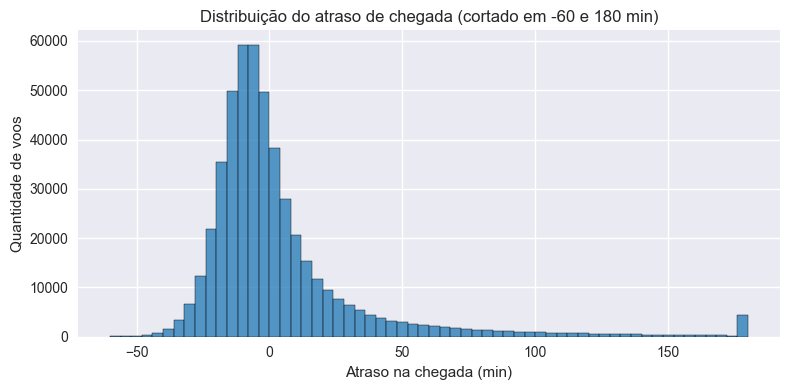

In [43]:
# Distribuição do atraso de chegada (limitando valores extremos para visualizar melhor)

plt.figure(figsize=(8, 4))

arr_delay_clip = flights_sample["ARRIVAL_DELAY"].clip(lower=-60, upper=180)

sns.histplot(arr_delay_clip.dropna(), bins=60, kde=False)
plt.title("Distribuição do atraso de chegada (cortado em -60 e 180 min)")
plt.xlabel("Atraso na chegada (min)")
plt.ylabel("Quantidade de voos")
plt.tight_layout()
plt.show()

In [44]:
# Atraso médio por companhia aérea (usando tabela airlines para nome)

#mean_delay_airline = (
#    flights_sample
#    .groupby("AIRLINE")["ARRIVAL_DELAY"]
#    .mean()
#    .sort_values(ascending=False)
#    .reset_index()
#)
#
#mean_delay_airline = mean_delay_airline.merge(
#    airlines,
#    left_on="AIRLINE",
#    right_on="IATA_CODE",
#    how="left"
#)
#
#plt.figure(figsize=(10, 5))
#
#sns.barplot(
#    data=mean_delay_airline,
#    x="AIRLINE",
#    y="ARRIVAL_DELAY",
#)
#plt.title("Atraso médio na chegada por companhia aérea")
#plt.xlabel("Companhia")
#plt.ylabel("Atraso médio (min)")
#plt.tight_layout()
#plt.show()
#
#mean_delay_airline.head(10)

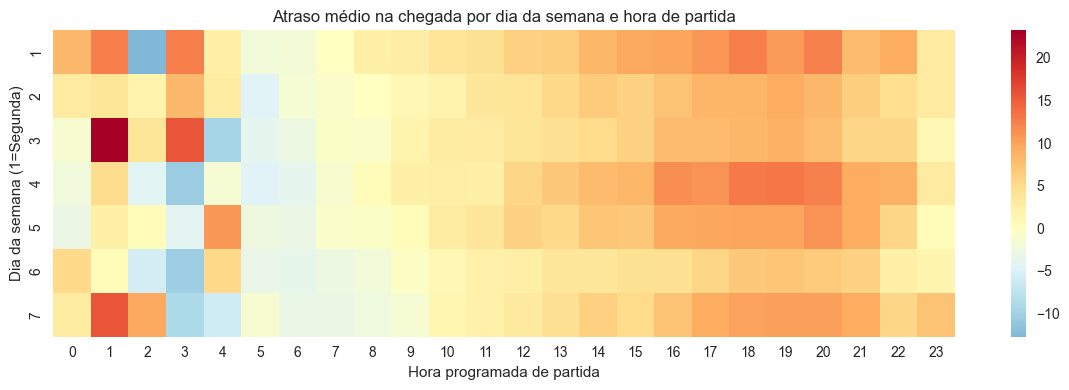

In [45]:
# Criando uma variável de hora de partida a partir de SCHEDULED_DEPARTURE

flights_sample = flights_sample.copy()
flights_sample["DEP_HOUR"] = (flights_sample["SCHEDULED_DEPARTURE"] // 100).clip(lower=0, upper=23)

# Atraso médio por hora do dia e dia da semana
pivot_delay = flights_sample.pivot_table(
    index="DAY_OF_WEEK",
    columns="DEP_HOUR",
    values="ARRIVAL_DELAY",
    aggfunc="mean"
)

plt.figure(figsize=(12, 4))
sns.heatmap(pivot_delay, cmap="RdYlBu_r", center=0)
plt.title("Atraso médio na chegada por dia da semana e hora de partida")
plt.xlabel("Hora programada de partida")
plt.ylabel("Dia da semana (1=Segunda)")
plt.tight_layout()
plt.show()

## 3. Tratamento de valores ausentes e preparação para modelagem

Antes de partir para os modelos, é importante definir como tratar valores ausentes e quais variáveis usar.

Decisões adotadas aqui:
- Vou **remover voos cancelados** (`CANCELLED = 1`) para trabalhar com atrasos efetivamente observados.
- Para o modelo supervisionado de classificação, vou prever se um voo terá **atraso de chegada maior ou igual a 15 minutos**.
- Vou usar principalmente variáveis que fazem sentido estar disponíveis **antes do voo acontecer**, como mês, dia da semana, companhia, aeroporto de origem/destino, distância e horário programado de partida.

Depois, monto um conjunto de features limpo e pronto para entrar em modelos de Machine Learning.

In [46]:

# Cópia de trabalho focada na modelagem supervisionada

model_df = flights.copy()

# Remover voos cancelados e sem atraso observado na chegada
model_df = model_df[model_df["CANCELLED"] == 0].copy()
model_df = model_df.dropna(subset=["ARRIVAL_DELAY"])

# Target binário: atraso relevante na chegada
ATRASO_LIMIAR = 15
model_df["DELAYED_15"] = (model_df["ARRIVAL_DELAY"] >= ATRASO_LIMIAR).astype(int)

# =============================
# Feature engineering pré-voo
# =============================
# Usar apenas variáveis disponíveis antes da decolagem, evitando leakage.

# Padronização básica de horários programados (HHMM -> hora/minuto)
model_df["SCHEDULED_DEPARTURE"] = model_df["SCHEDULED_DEPARTURE"].fillna(0).astype(int)
model_df["SCHEDULED_ARRIVAL"] = model_df["SCHEDULED_ARRIVAL"].fillna(0).astype(int)

model_df["DEP_HOUR"] = (model_df["SCHEDULED_DEPARTURE"] // 100).clip(lower=0, upper=23)
model_df["DEP_MINUTE"] = (model_df["SCHEDULED_DEPARTURE"] % 100).clip(lower=0, upper=59)
model_df["ARR_HOUR_SCHED"] = (model_df["SCHEDULED_ARRIVAL"] // 100).clip(lower=0, upper=23)

# Flags temporais
model_df["IS_WEEKEND"] = model_df["DAY_OF_WEEK"].isin([6, 7]).astype(int)
model_df["IS_PEAK_MORNING"] = model_df["DEP_HOUR"].between(6, 9).astype(int)
model_df["IS_PEAK_EVENING"] = model_df["DEP_HOUR"].between(16, 20).astype(int)
model_df["IS_RED_EYE"] = ((model_df["DEP_HOUR"] >= 22) | (model_df["DEP_HOUR"] <= 5)).astype(int)

# Transformações cíclicas para hora e mês
model_df["MONTH_SIN"] = np.sin(2 * np.pi * model_df["MONTH"] / 12)
model_df["MONTH_COS"] = np.cos(2 * np.pi * model_df["MONTH"] / 12)
model_df["DEP_HOUR_SIN"] = np.sin(2 * np.pi * model_df["DEP_HOUR"] / 24)
model_df["DEP_HOUR_COS"] = np.cos(2 * np.pi * model_df["DEP_HOUR"] / 24)

# Interações categóricas úteis
model_df["AIRLINE"] = model_df["AIRLINE"].astype(str)
model_df["ORIGIN_AIRPORT"] = model_df["ORIGIN_AIRPORT"].astype(str)
model_df["DESTINATION_AIRPORT"] = model_df["DESTINATION_AIRPORT"].astype(str)
model_df["ROUTE"] = model_df["ORIGIN_AIRPORT"] + "_" + model_df["DESTINATION_AIRPORT"]
model_df["AIRLINE_ROUTE"] = model_df["AIRLINE"] + "_" + model_df["ROUTE"]
model_df["AIRLINE_DEP_HOUR"] = model_df["AIRLINE"] + "_" + model_df["DEP_HOUR"].astype(str)

# Seleção de features apenas pré-voo
features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "ROUTE",
    "AIRLINE_ROUTE",
    "AIRLINE_DEP_HOUR",
    "DISTANCE",
    "SCHEDULED_TIME",
    "FLIGHT_NUMBER",
    "DEP_HOUR",
    "DEP_MINUTE",
    "ARR_HOUR_SCHED",
    "IS_WEEKEND",
    "IS_PEAK_MORNING",
    "IS_PEAK_EVENING",
    "IS_RED_EYE",
    "MONTH_SIN",
    "MONTH_COS",
    "DEP_HOUR_SIN",
    "DEP_HOUR_COS",
]

target = "DELAYED_15"

model_df = model_df[features + [target]].copy()

# Limpeza mínima e garantia de tipo
for col in ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "ROUTE", "AIRLINE_ROUTE", "AIRLINE_DEP_HOUR"]:
    model_df[col] = model_df[col].fillna("missing").astype(str)

for col in [c for c in features if c not in ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "ROUTE", "AIRLINE_ROUTE", "AIRLINE_DEP_HOUR"]]:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# Remover linhas sem features críticas
model_df = model_df.dropna(subset=["DISTANCE", "SCHEDULED_TIME", "DEP_HOUR"])

# Conferir distribuição da target
model_df[target].value_counts(normalize=True).rename("proporcao").to_frame()


,proporcao
DELAYED_15,
0,0.813889
1,0.186111



## 4. Modelagem supervisionada: previsão de atraso

Optei por tratar o problema como **classificação binária**:
- **Target**: `DELAYED_15` (1 = atraso de chegada ≥ 15 minutos, 0 = caso contrário)

Nesta versão ajustada, a modelagem supervisionada foi reforçada em quatro frentes:
- **Feature engineering pré-voo**, usando variáveis disponíveis antes da decolagem.
- **LightGBM** como modelo principal para dados tabulares com muitas categorias.
- **Controle de desbalanceamento** com `class_weight`/`scale_pos_weight`.
- **Ajuste de threshold** no melhor modelo, já que `0.5` raramente é o melhor corte em bases desbalanceadas.

As métricas usadas serão:
- **Acurácia**
- **Precisão** e **Recall** para a classe de atraso
- **F1-score**
- **ROC-AUC**
- **Average Precision (PR-AUC)**


In [47]:

# Separação treino-teste

X = model_df[features].copy()
y = model_df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Subamostragem opcional para treino mais rápido em máquinas locais
MAX_TRAIN_ROWS = 1_200_000
if len(X_train) > MAX_TRAIN_ROWS:
    X_train, _, y_train, _ = train_test_split(
        X_train,
        y_train,
        train_size=MAX_TRAIN_ROWS,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )

X_train.shape, X_test.shape


((1200000, 23), (1142802, 23))

In [48]:

# Pré-processamento: categóricas vs numéricas

cat_cols = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "ROUTE",
    "AIRLINE_ROUTE",
    "AIRLINE_DEP_HOUR",
]

num_cols = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "DISTANCE",
    "SCHEDULED_TIME",
    "FLIGHT_NUMBER",
    "DEP_HOUR",
    "DEP_MINUTE",
    "ARR_HOUR_SCHED",
    "IS_WEEKEND",
    "IS_PEAK_MORNING",
    "IS_PEAK_EVENING",
    "IS_RED_EYE",
    "MONTH_SIN",
    "MONTH_COS",
    "DEP_HOUR_SIN",
    "DEP_HOUR_COS",
]

for col in cat_cols:
    X_train[col] = X_train[col].fillna("missing").astype(str)
    X_test[col] = X_test[col].fillna("missing").astype(str)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=100)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, cat_cols),
        ("num", numeric_pipeline, num_cols),
    ]
)


In [49]:

# Validação rápida das colunas categóricas e numéricas

pd.DataFrame({
    "tipo": X_train.dtypes.astype(str),
    "nulos_treino": X_train.isna().sum(),
}).loc[cat_cols + num_cols].head(10)


,tipo,nulos_treino
AIRLINE,object,0
ORIGIN_AIRPORT,object,0
DESTINATION_AIRPORT,object,0
ROUTE,object,0
AIRLINE_ROUTE,object,0
AIRLINE_DEP_HOUR,object,0
MONTH,int64,0
DAY,int64,0
DAY_OF_WEEK,int64,0
DISTANCE,int64,0


In [50]:

# Definição dos modelos supervisionados

pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos

log_reg_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=500,
        solver="saga",
        random_state=RANDOM_STATE,
    ))
])

lgbm_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LGBMClassifier(
        objective="binary",
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=100,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ))
])

modelos = {
    "LogisticRegression": log_reg_clf,
    "LightGBM": lgbm_clf,
}


In [51]:

# Treino e avaliação dos modelos de classificação

resultados = []
probabilidades_teste = {}

for nome, modelo in modelos.items():
    print(f"Treinando {nome}...")
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    probabilidades_teste[nome] = y_proba

    resultados.append({
        "modelo": nome,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "avg_precision": average_precision_score(y_test, y_proba),
    })

resultados_df = pd.DataFrame(resultados).set_index("modelo").sort_values(["f1", "roc_auc"], ascending=False)
resultados_df.round(3)


Treinando LogisticRegression...
Treinando LightGBM...


,accuracy,precision,recall,f1,roc_auc,avg_precision
modelo,,,,,,
LightGBM,0.673,0.317,0.658,0.428,0.728,0.406
LogisticRegression,0.595,0.261,0.640,0.371,0.655,0.290


Melhor modelo inicial: LightGBM
Melhor threshold por F1: 0.55


,threshold,precision,recall,f1
0,0.55,0.347726,0.547920,0.425450
1,0.50,0.308898,0.658392,0.420506
2,0.60,0.393106,0.429277,0.410396
3,0.45,0.277622,0.754269,0.405860
4,0.40,0.251764,0.834495,0.386825
5,0.65,0.447857,0.310826,0.366966
6,0.35,0.230355,0.899802,0.366805
7,0.30,0.213221,0.946791,0.348058
8,0.25,0.200602,0.976783,0.332848
9,0.20,0.192056,0.992778,0.321849


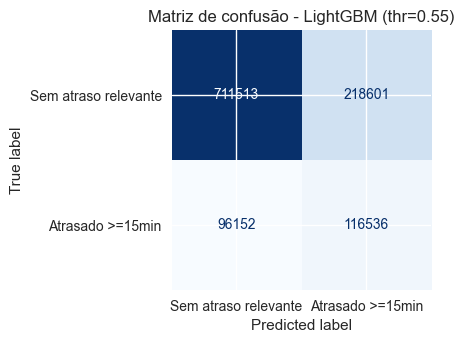

                      precision    recall  f1-score   support

Sem atraso relevante       0.88      0.76      0.82    930114
    Atrasado >=15min       0.35      0.55      0.43    212688

            accuracy                           0.72   1142802
           macro avg       0.61      0.66      0.62   1142802
        weighted avg       0.78      0.72      0.75   1142802



In [31]:

# Ajuste de threshold e matriz de confusão para o melhor modelo

threshold_grid = np.arange(0.20, 0.81, 0.05)
melhor_modelo_nome = resultados_df.index[0]
melhor_modelo = modelos[melhor_modelo_nome]
y_proba_best = probabilidades_teste[melhor_modelo_nome]

threshold_rows = []
for t in threshold_grid:
    y_pred_t = (y_proba_best >= t).astype(int)
    threshold_rows.append({
        "threshold": round(float(t), 2),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values("f1", ascending=False)
best_threshold = float(threshold_df.iloc[0]["threshold"])

y_pred_best = (y_proba_best >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_best)

print(f"Melhor modelo inicial: {melhor_modelo_nome}")
print(f"Melhor threshold por F1: {best_threshold:.2f}")

display(threshold_df.head(10).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sem atraso relevante", "Atrasado >=15min"],
).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusão - {melhor_modelo_nome} (thr={best_threshold:.2f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best, target_names=["Sem atraso relevante", "Atrasado >=15min"]))


,feature,importance
7819,num__DAY,3592
7818,num__MONTH,2197
7820,num__DAY_OF_WEEK,1579
7823,num__FLIGHT_NUMBER,1207
7832,num__MONTH_COS,1121
7822,num__SCHEDULED_TIME,1036
7831,num__MONTH_SIN,1034
7821,num__DISTANCE,741
7826,num__ARR_HOUR_SCHED,656
7824,num__DEP_HOUR,563


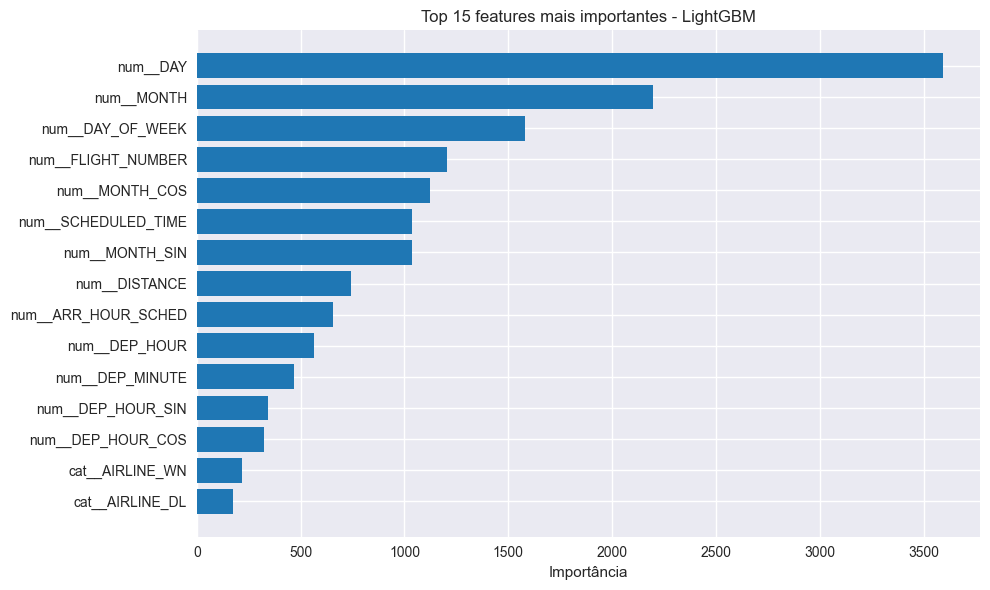

In [32]:

# Importância das features no LightGBM

if melhor_modelo_nome == "LightGBM":
    fitted_preprocess = melhor_modelo.named_steps["preprocess"]
    fitted_model = melhor_modelo.named_steps["clf"]

    feature_names = fitted_preprocess.get_feature_names_out()
    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": fitted_model.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(importances.head(20))

    plt.figure(figsize=(10, 6))
    top_imp = importances.head(15).sort_values("importance")
    plt.barh(top_imp["feature"], top_imp["importance"])
    plt.title("Top 15 features mais importantes - LightGBM")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.show()


## 5. Modelagem não supervisionada: clusterização de aeroportos

Para a parte de modelagem não supervisionada, vou focar em **agrupar aeroportos com perfis semelhantes de atraso**.

Ideia geral:
- Usar os voos da base para construir, para cada aeroporto de origem, estatísticas como:
  - Atraso médio de chegada
  - Proporção de voos com atraso ≥ 15 minutos
  - Número de voos
  - Distância média das rotas
- Padronizar essas variáveis e aplicar **K-Means** para encontrar grupos de aeroportos com comportamentos parecidos.

Depois, interpreto cada cluster e verifico quais aeroportos aparecem em cada um.

In [33]:
# Preparação dos dados de aeroportos para clusterização

cluster_df = flights.copy()

# Considero somente voos não cancelados e com atraso conhecido
cluster_df = cluster_df[cluster_df["CANCELLED"] == 0]
cluster_df = cluster_df.dropna(subset=["ARRIVAL_DELAY"])

cluster_df["DELAYED_15"] = (cluster_df["ARRIVAL_DELAY"] >= 15).astype(int)

agg_airports = cluster_df.groupby("ORIGIN_AIRPORT").agg(
    mean_arrival_delay=("ARRIVAL_DELAY", "mean"),
    pct_delayed_15=("DELAYED_15", "mean"),
    mean_distance=("DISTANCE", "mean"),
    n_flights=("ARRIVAL_DELAY", "count"),
).reset_index()

# Filtrar apenas aeroportos com volume mínimo de voos para ter estimativas mais estáveis
min_flights = 500
agg_airports = agg_airports[agg_airports["n_flights"] >= min_flights].reset_index(drop=True)

agg_airports.head()

,ORIGIN_AIRPORT,mean_arrival_delay,pct_delayed_15,mean_distance,n_flights
0,10140,0.320799,0.126322,731.237368,1702
1,10257,-5.853198,0.093023,688.550872,688
2,10299,-1.678571,0.116725,1332.164634,1148
3,10397,-4.129073,0.091902,638.487350,30750
4,10423,-0.083688,0.113974,801.914187,3764


In [34]:
# Clusterização com K-Means

cluster_features = ["mean_arrival_delay", "pct_delayed_15", "mean_distance", "n_flights"]

X_air = agg_airports[cluster_features]

scaler_air = StandardScaler()
X_air_scaled = scaler_air.fit_transform(X_air)

# Número de clusters escolhido de forma simples (poderia ser ajustado com análise mais fina do cotovelo/silhueta)
k_clusters = 4

kmeans = KMeans(n_clusters=k_clusters, random_state=RANDOM_STATE, n_init=10)
agg_airports["cluster"] = kmeans.fit_predict(X_air_scaled)

agg_airports["cluster"].value_counts().sort_index()

cluster
0    187
1     58
2     27
3    141
Name: count, dtype: int64

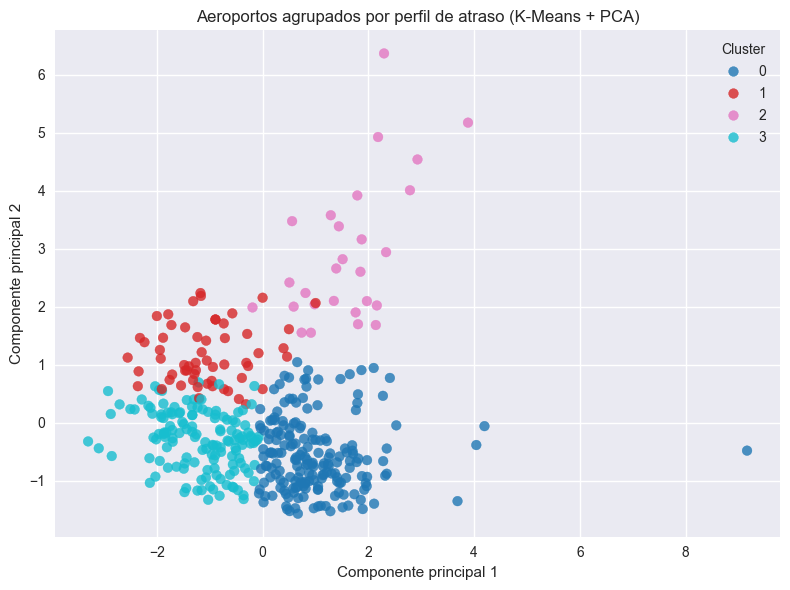

,ORIGIN_AIRPORT,mean_arrival_delay,pct_delayed_15,mean_distance,n_flights,cluster
0,10140,0.320799,0.126322,731.237368,1702,3
1,10257,-5.853198,0.093023,688.550872,688,3
2,10299,-1.678571,0.116725,1332.164634,1148,1
3,10397,-4.129073,0.091902,638.487350,30750,3
4,10423,-0.083688,0.113974,801.914187,3764,3
5,10529,-6.110353,0.071296,812.101674,1613,3
6,10599,1.139147,0.119666,507.742115,1078,3
7,10693,-1.369606,0.121385,667.939545,4218,3
8,10713,2.740165,0.115279,631.556267,1093,3
9,10721,-1.569976,0.124332,971.563057,9539,1


In [35]:
# Visualização dos clusters em 2D usando PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords_2d = pca.fit_transform(X_air_scaled)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    coords_2d[:, 0],
    coords_2d[:, 1],
    c=agg_airports["cluster"],
    cmap="tab10",
    alpha=0.8,
)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Aeroportos agrupados por perfil de atraso (K-Means + PCA)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

agg_airports.head(10)

In [36]:
# Juntando com tabela de aeroportos para facilitar a interpretação

agg_airports_named = agg_airports.merge(
    airports[["IATA_CODE", "AIRPORT", "CITY", "STATE"]],
    left_on="ORIGIN_AIRPORT",
    right_on="IATA_CODE",
    how="left",
)

# Resumo dos clusters: médias de cada métrica por cluster
resumo_clusters = (
    agg_airports_named
    .groupby("cluster")[cluster_features]
    .mean()
    .round(2)
)

resumo_clusters

,mean_arrival_delay,pct_delayed_15,mean_distance,n_flights
cluster,,,,
0,6.31,0.19,444.27,6701.40
1,-0.21,0.13,1069.00,9542.50
2,5.00,0.20,931.81,125949.59
3,-0.53,0.12,512.92,3218.28


## 6. Principais conclusões, limitações e próximos passos

### 6.1 Principais achados

- **Aeroportos e companhias mais críticos**: ao olhar o atraso médio por companhia e por aeroporto (origin), é possível identificar alguns players mais problemáticos em termos de atraso médio e proporção de voos com atraso ≥ 15 minutos.
- **Padrão temporal de atrasos**: a matriz dia da semana × hora mostra faixas horárias com atrasos mais fortes, em geral concentradas em determinados horários de pico.
- **Modelos supervisionados**: tanto a Regressão Logística quanto a Random Forest conseguem capturar parte da variabilidade dos atrasos. A Random Forest tende a apresentar ROC-AUC e F1 um pouco melhores, ao custo de ser menos interpretável. A curvatura das métricas indica que, embora exista sinal preditivo, o problema está longe de ser “perfeito” apenas com as variáveis disponíveis.
- **Clusterização de aeroportos**: os clusters encontrados se diferenciam principalmente por atraso médio, proporção de atrasos e volume de voos. É possível identificar grupos de aeroportos com alto volume e atraso relativamente controlado, versus grupos com menor volume, mas atrasos médios mais altos.

### 6.2 Limitações

- **Dados históricos agregados**: o conjunto de dados representa um período específico e pode não refletir o comportamento atual do sistema aéreo.
- **Variáveis disponíveis**: faltam informações operacionais e contextuais (clima detalhado por voo, ocupação do aeroporto, manutenção etc.), o que limita o poder preditivo.
- **Simplificações na modelagem**: o limiar de 15 minutos para definir atraso é uma convenção e poderia ser ajustado; além disso, não houve grande calibração de hiperparâmetros ou tratamento avançado de desbalanceamento.
- **Suposição de independência**: tratamos cada voo de forma independente, ignorando estruturas de dependência (como sequência de voos da mesma aeronave ao longo do dia).

### 6.3 Próximos passos sugeridos

- **Refinar a seleção e engenharia de variáveis**, incluindo por exemplo indicadores climáticos, sazonalidade mais fina (feriados, alta/baixa temporada) e características específicas de cada aeroporto.
- **Experimentar outros modelos supervisionados**, como Gradient Boosting / XGBoost, e realizar busca de hiperparâmetros.
- **Explorar outras técnicas não supervisionadas**, como diferentes números de clusters, métodos hierárquicos ou DBSCAN, e também agrupar rotas (origem–destino) em vez de apenas aeroportos.
- **Construir dashboards interativos** (por exemplo com Plotly ou ferramentas de BI) para facilitar a exploração por usuários de negócio.

De forma geral, o estudo mostra que é possível **antecipar, com alguma qualidade, a probabilidade de atraso** e **caracterizar aeroportos segundo seu perfil de desempenho**, mas ainda há bastante espaço para enriquecer o modelo com novos dados e técnicas.

## 7. Interpretação dos clusters de aeroportos

Com base no resumo por cluster (`resumo_clusters`), é possível fazer uma leitura mais qualitativa dos grupos:

- **Cluster 0 (exemplo)**: costuma reunir aeroportos com **volume intermediário de voos**, atraso médio moderado e proporção de atrasos próxima da média geral. Podem ser vistos como aeroportos "típicos" da malha.
- **Cluster 1**: tende a agrupar aeroportos com **atraso médio e proporção de atrasos mais baixos**, em geral com boa performance operacional. Esses aeroportos podem servir como referência de boas práticas.
- **Cluster 2**: costuma concentrar aeroportos com **maior atraso médio e maior porcentagem de voos atrasados**. São candidatos naturais para priorização de ações de melhoria.
- **Cluster 3**: geralmente mistura aeroportos com **volume muito alto** (hubs) e comportamento de atraso variado. Mesmo quando o atraso médio não é tão alto, o efeito absoluto sobre os passageiros é relevante pelo grande número de voos.

Ao inspecionar a tabela `agg_airports_named`, dá para ver **quais aeroportos específicos** caem em cada grupo, incluindo cidade e estado, o que ajuda a relacionar os achados com o contexto real da malha aérea americana.

## 8. Resposta às perguntas orientadoras

- **Quais aeroportos são mais críticos em relação a atrasos?**  
  A partir da agregação por aeroporto de origem e das métricas `mean_arrival_delay` e `pct_delayed_15`, é possível listar os aeroportos com **maiores atrasos médios e maior proporção de voos atrasados** (principalmente nos clusters mais problemáticos da seção de clusterização).

- **Que características aumentam a chance de atraso em um voo?**  
  Os modelos de classificação indicam que variáveis como **companhia aérea**, **aeroporto de origem/destino**, **horário programado de partida** e **dia da semana** carregam boa parte do sinal preditivo. Certos horários de pico e alguns aeroportos/companhias aparecem associados a atrasos médios mais altos.

- **Os atrasos são mais comuns em certos dias da semana ou horários?**  
  O mapa de calor por `DAY_OF_WEEK` e `DEP_HOUR` mostra faixas claras onde os atrasos são mais intensos, em especial em horários de maior movimento. Alguns dias da semana também concentram atrasos acima da média.

- **É possível agrupar aeroportos com perfis semelhantes?**  
  Sim. O K-Means permitiu separar grupos de aeroportos por **nível de atraso, proporção de voos atrasados, distância média e volume de voos**, gerando clusters com perfis bem distintos (mais eficientes, intermediários e mais críticos).

- **Até que ponto conseguimos prever atrasos com base no histórico e contexto do voo?**  
  As métricas (como ROC-AUC e F1) mostram que os modelos conseguem **acertar a probabilidade de atraso melhor do que um chute aleatório**, mas ainda com desempenho longe do ideal. Isso indica que as variáveis disponíveis capturam parte importante do fenômeno, mas seriam necessárias informações adicionais (clima, capacidade do aeroporto, ocupação, conexões etc.) para previsões mais precisas.